In [1]:
# ============================================================
# WEEK 7 — DEEP LEARNING FOR IMAGE CLASSIFICATION
# ============================================================

# ============================================================
# STEP 0 — IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

np.random.seed(42)

tf.random.set_seed(42)

print("="*60)
print("WEEK 7 LIBRARIES LOADED SUCCESSFULLY")
print("="*60)

print("TensorFlow Version:", tf.__version__)

WEEK 7 LIBRARIES LOADED SUCCESSFULLY
TensorFlow Version: 2.21.0


LOADING CIFAR-10 DATASET
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 52s 0us/step

Training Images Shape:
(50000, 32, 32, 3)

Training Labels Shape:
(50000, 1)

Testing Images Shape:
(10000, 32, 32, 3)

Testing Labels Shape:
(10000, 1)

Classes:
0 -> airplane
1 -> automobile
2 -> bird
3 -> cat
4 -> deer
5 -> dog
6 -> frog
7 -> horse
8 -> ship
9 -> truck


DATASET SUMMARY
Training Samples: 50,000
Testing Samples: 10,000
Number of Classes: 10


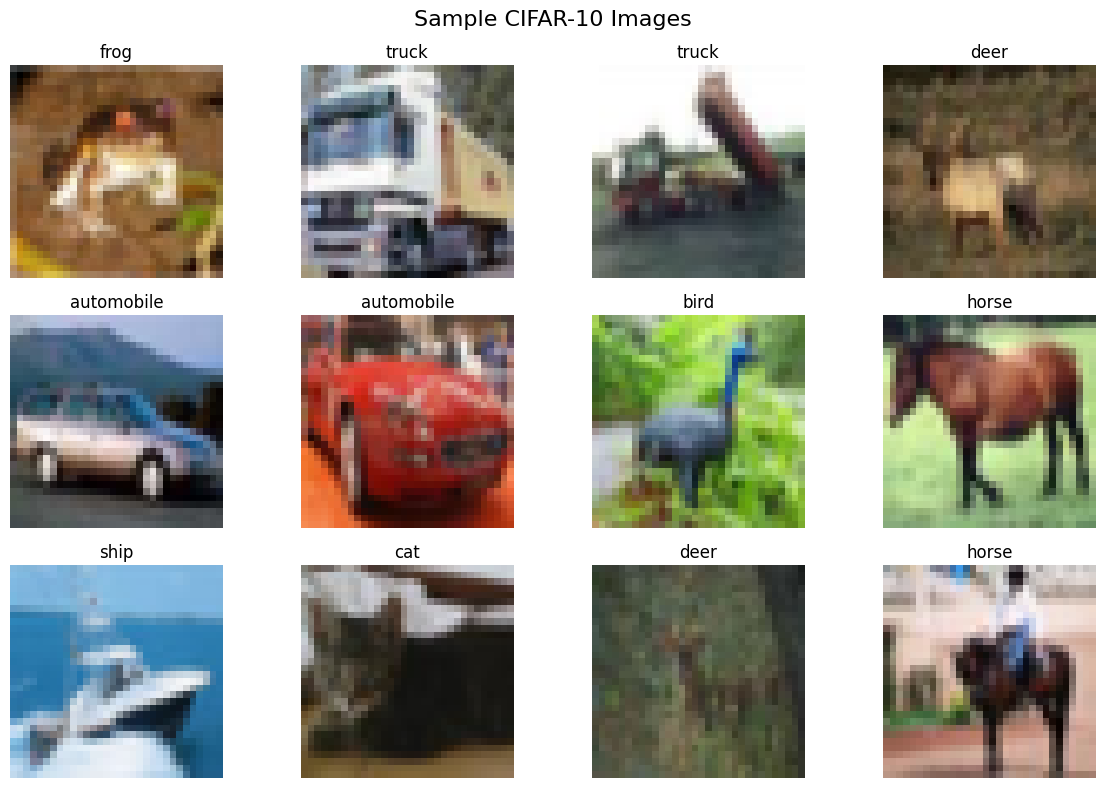


OBSERVATION:

The CIFAR-10 dataset contains 60,000 color images
belonging to 10 object categories.

Each image has a size of 32×32 pixels with
3 color channels (RGB).

The dataset is balanced and suitable for
multi-class image classification tasks.



In [2]:
# ============================================================
# STEP 1 — ENVIRONMENT CHECK & DATASET LOADING
# ============================================================

print("="*60)
print("LOADING CIFAR-10 DATASET")
print("="*60)

# =========================
# LOAD DATASET
# =========================

(X_train, y_train), (X_test, y_test) = (
    keras.datasets.cifar10.load_data()
)

# =========================
# SHAPES
# =========================

print("\nTraining Images Shape:")
print(X_train.shape)

print("\nTraining Labels Shape:")
print(y_train.shape)

print("\nTesting Images Shape:")
print(X_test.shape)

print("\nTesting Labels Shape:")
print(y_test.shape)

# =========================
# CLASS NAMES
# =========================

class_names = [

    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",

    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print("\nClasses:")

for i, cls in enumerate(class_names):

    print(f"{i} -> {cls}")

# =========================
# DATASET SUMMARY
# =========================

print("\n")
print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Training Samples: {len(X_train):,}")

print(f"Testing Samples: {len(X_test):,}")

print(f"Number of Classes: {len(class_names)}")

# =========================
# DISPLAY SAMPLE IMAGES
# =========================

plt.figure(figsize=(12,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(X_train[i])

    plt.title(
        class_names[
            y_train[i][0]
        ]
    )

    plt.axis("off")

plt.suptitle(
    "Sample CIFAR-10 Images",
    fontsize=16
)

plt.tight_layout()

plt.show()

# =========================
# OBSERVATION
# =========================

print("""
OBSERVATION:

The CIFAR-10 dataset contains 60,000 color images
belonging to 10 object categories.

Each image has a size of 32×32 pixels with
3 color channels (RGB).

The dataset is balanced and suitable for
multi-class image classification tasks.
""")

CLASS DISTRIBUTION


,Class,Count
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


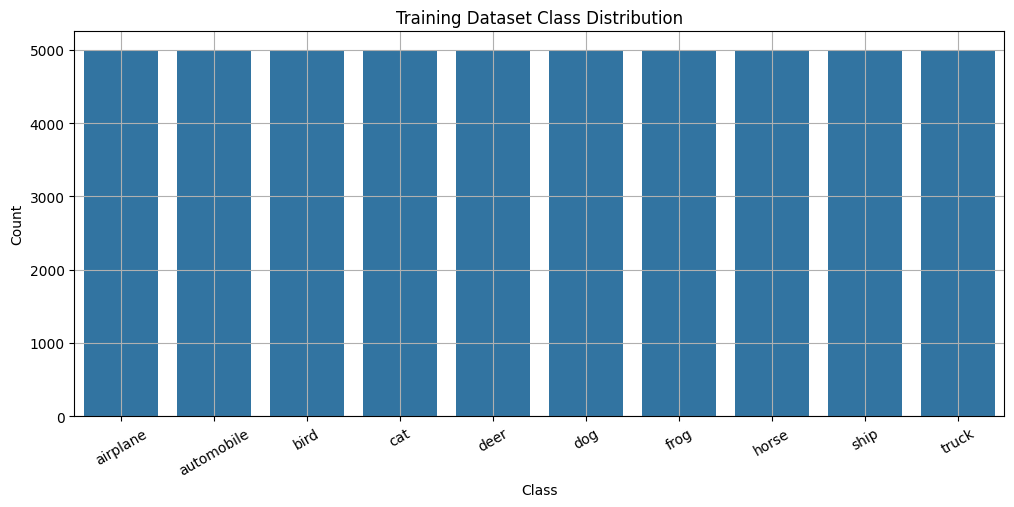

IMAGE INFORMATION
Image Height : 32
Image Width : 32
Channels : 3
Total Pixels : 1024

Pixel Statistics
Minimum Pixel Value : 0
Maximum Pixel Value : 255
Mean Pixel Value : 120.71
Standard Deviation : 64.15
RGB CHANNEL ANALYSIS


,Channel,Mean Pixel Value
0,Red,125.306918
1,Green,122.950394
2,Blue,113.865383



OBSERVATION:

The CIFAR-10 dataset is balanced with an equal number
of images per class. This prevents class imbalance
issues and allows fair evaluation of image
classification models.



In [3]:
# ============================================================
# STEP 2 — DATA EXPLORATION & CLASS DISTRIBUTION
# ============================================================

# =========================
# CLASS DISTRIBUTION
# =========================

train_labels_flat = y_train.flatten()

class_counts = pd.Series(
    train_labels_flat
).value_counts().sort_index()

distribution_df = pd.DataFrame({

    "Class": class_names,

    "Count": class_counts.values
})

print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)

display(distribution_df)

# =========================
# BAR CHART
# =========================

plt.figure(figsize=(12,5))

sns.barplot(

    x="Class",

    y="Count",

    data=distribution_df
)

plt.title(
    "Training Dataset Class Distribution"
)

plt.xticks(rotation=30)

plt.grid(True)

plt.show()

# =========================
# IMAGE DIMENSIONS
# =========================

print("="*60)
print("IMAGE INFORMATION")
print("="*60)

print(
    f"Image Height : {X_train.shape[1]}"
)

print(
    f"Image Width : {X_train.shape[2]}"
)

print(
    f"Channels : {X_train.shape[3]}"
)

print(
    f"Total Pixels : "
    f"{X_train.shape[1] * X_train.shape[2]}"
)

# =========================
# PIXEL VALUE RANGE
# =========================

print("\nPixel Statistics")

print(
    f"Minimum Pixel Value : {X_train.min()}"
)

print(
    f"Maximum Pixel Value : {X_train.max()}"
)

print(
    f"Mean Pixel Value : "
    f"{X_train.mean():.2f}"
)

print(
    f"Standard Deviation : "
    f"{X_train.std():.2f}"
)

# =========================
# RGB CHANNEL ANALYSIS
# =========================

rgb_means = X_train.mean(
    axis=(0,1,2)
)

rgb_df = pd.DataFrame({

    "Channel":[
        "Red",
        "Green",
        "Blue"
    ],

    "Mean Pixel Value":
    rgb_means
})

print("="*60)
print("RGB CHANNEL ANALYSIS")
print("="*60)

display(rgb_df)

print("""
OBSERVATION:

The CIFAR-10 dataset is balanced with an equal number
of images per class. This prevents class imbalance
issues and allows fair evaluation of image
classification models.
""")

In [4]:
# ============================================================
# STEP 3 — IMAGE PREPROCESSING & NORMALIZATION
# ============================================================

print("="*60)
print("IMAGE PREPROCESSING")
print("="*60)

# =========================
# NORMALIZATION
# =========================

X_train_norm = X_train.astype(
    "float32"
) / 255.0

X_test_norm = X_test.astype(
    "float32"
) / 255.0

print("\nNormalization Complete")

# =========================
# VERIFY RANGE
# =========================

print("\nTraining Range")

print(
    f"Min: {X_train_norm.min():.4f}"
)

print(
    f"Max: {X_train_norm.max():.4f}"
)

# =========================
# ONE HOT ENCODING
# =========================

y_train_cat = to_categorical(
    y_train,
    10
)

y_test_cat = to_categorical(
    y_test,
    10
)

print("\nOne-Hot Encoding Complete")

print(
    "Training Labels Shape:",
    y_train_cat.shape
)

print(
    "Testing Labels Shape:",
    y_test_cat.shape
)

# =========================
# SAMPLE ENCODED LABEL
# =========================

print("\nExample")

print(
    "Original Label:",
    y_train[0][0]
)

print(
    "Encoded Label:"
)

print(
    y_train_cat[0]
)

# =========================
# MEMORY CHECK
# =========================

print("\nTraining Data Shape")

print(X_train_norm.shape)

print("\nTesting Data Shape")

print(X_test_norm.shape)

print("""
OBSERVATION:

Pixel values have been normalized from the range
0–255 to 0–1. This improves neural network training
stability and convergence speed.

Labels have been converted to one-hot encoded vectors
for multi-class classification.
""")

IMAGE PREPROCESSING

Normalization Complete

Training Range
Min: 0.0000
Max: 1.0000

One-Hot Encoding Complete
Training Labels Shape: (50000, 10)
Testing Labels Shape: (10000, 10)

Example
Original Label: 6
Encoded Label:
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Training Data Shape
(50000, 32, 32, 3)

Testing Data Shape
(10000, 32, 32, 3)

OBSERVATION:

Pixel values have been normalized from the range
0–255 to 0–1. This improves neural network training
stability and convergence speed.

Labels have been converted to one-hot encoded vectors
for multi-class classification.



DATA AUGMENTATION PREVIEW


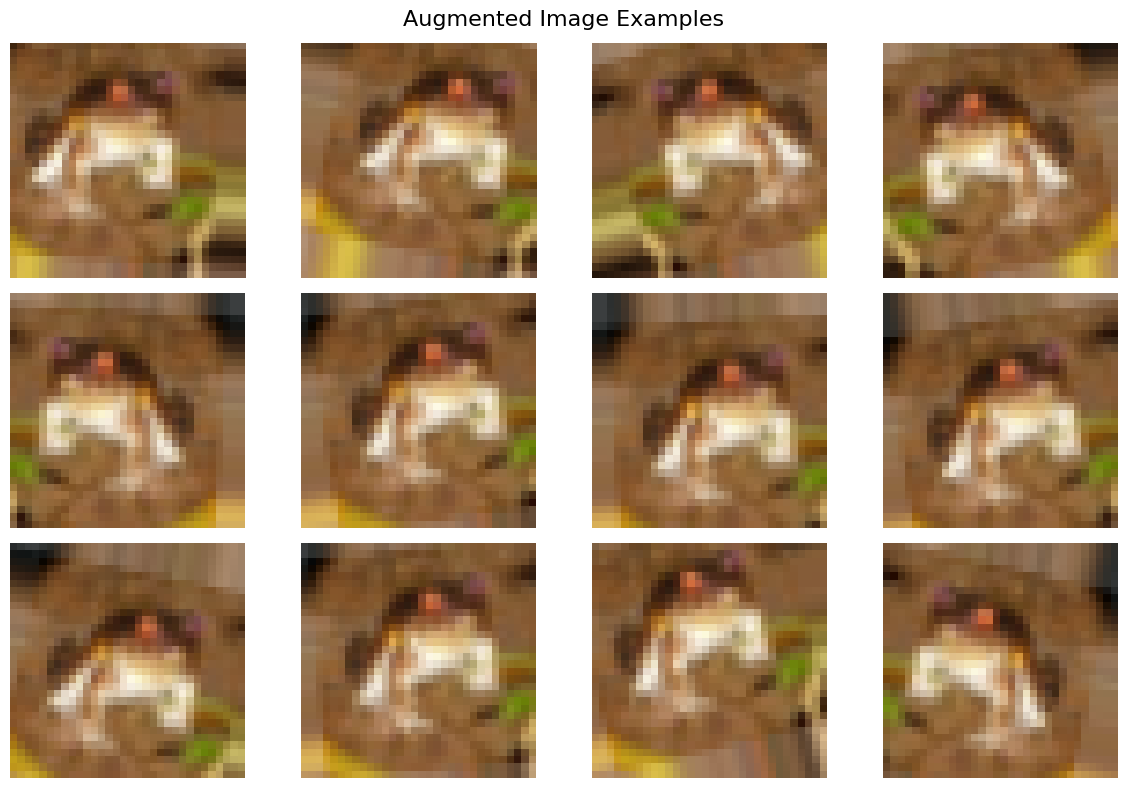

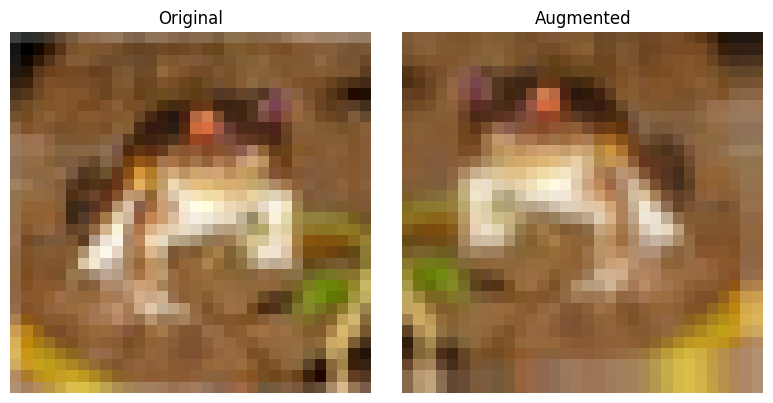


OBSERVATION:

Data augmentation artificially increases dataset
diversity by generating modified versions of existing
images.

This helps reduce overfitting and improves CNN
generalization performance.



In [5]:
# ============================================================
# STEP 4 — DATA VISUALIZATION & AUGMENTATION PREVIEW
# ============================================================

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

print("="*60)
print("DATA AUGMENTATION PREVIEW")
print("="*60)

# =========================
# DATA AUGMENTATION
# =========================

datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)

# =========================
# SAMPLE IMAGE
# =========================

sample_image = X_train_norm[0]

sample_image = np.expand_dims(
    sample_image,
    axis=0
)

# =========================
# AUGMENTED IMAGES
# =========================

plt.figure(figsize=(12,8))

i = 0

for batch in datagen.flow(

    sample_image,

    batch_size=1
):

    plt.subplot(3,4,i+1)

    plt.imshow(
        batch[0]
    )

    plt.axis("off")

    i += 1

    if i == 12:
        break

plt.suptitle(
    "Augmented Image Examples",
    fontsize=16
)

plt.tight_layout()

plt.show()

# =========================
# ORIGINAL VS AUGMENTED
# =========================

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)

plt.imshow(
    X_train_norm[0]
)

plt.title("Original")

plt.axis("off")

augmented_image = next(

    datagen.flow(
        sample_image,
        batch_size=1
    )
)[0]

plt.subplot(1,2,2)

plt.imshow(
    augmented_image
)

plt.title("Augmented")

plt.axis("off")

plt.tight_layout()

plt.show()

print("""
OBSERVATION:

Data augmentation artificially increases dataset
diversity by generating modified versions of existing
images.

This helps reduce overfitting and improves CNN
generalization performance.
""")

In [6]:
# ============================================================
# STEP 5 — BUILD BASELINE DENSE NEURAL NETWORK
# ============================================================

print("="*60)
print("BUILDING BASELINE DENSE NEURAL NETWORK")
print("="*60)

# =========================
# DENSE MODEL
# =========================

dense_model = Sequential([

    Flatten(
        input_shape=(32, 32, 3)
    ),

    Dense(
        512,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        10,
        activation="softmax"
    )
])

# =========================
# COMPILE MODEL
# =========================

dense_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

# =========================
# MODEL SUMMARY
# =========================

dense_model.summary()

print("""
OBSERVATION:

This serves as the baseline model for comparison.
Unlike CNNs, Dense Neural Networks do not learn
spatial image features effectively because images
are flattened before processing.
""")

BUILDING BASELINE DENSE NEURAL NETWORK


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


OBSERVATION:

This serves as the baseline model for comparison.
Unlike CNNs, Dense Neural Networks do not learn
spatial image features effectively because images
are flattened before processing.



In [7]:
# ============================================================
# STEP 6 — TRAIN BASELINE DENSE MODEL
# ============================================================

print("="*60)
print("TRAINING BASELINE MODEL")
print("="*60)

start_time = time.time()

dense_history = dense_model.fit(

    X_train_norm,

    y_train_cat,

    validation_split=0.2,

    epochs=30,

    batch_size=128,

    verbose=1
)

training_time = time.time() - start_time

print("\nTraining Time:")

print(
    f"{training_time:.2f} seconds"
)

# =========================
# FINAL RESULTS
# =========================

train_acc = dense_history.history[
    "accuracy"
][-1]

val_acc = dense_history.history[
    "val_accuracy"
][-1]

print("\nFinal Training Accuracy:")

print(f"{train_acc:.4f}")

print("\nFinal Validation Accuracy:")

print(f"{val_acc:.4f}")

print("""
OBSERVATION:

The baseline Dense Neural Network provides a benchmark
for later CNN and Transfer Learning models.
""")

TRAINING BASELINE MODEL
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2435 - loss: 2.0399 - val_accuracy: 0.3286 - val_loss: 1.8810
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3097 - loss: 1.8942 - val_accuracy: 0.3573 - val_loss: 1.8165
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3242 - loss: 1.8449 - val_accuracy: 0.3705 - val_loss: 1.7837
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3356 - loss: 1.8129 - val_accuracy: 0.3795 - val_loss: 1.7551
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3486 - loss: 1.7829 - val_accuracy: 0.3757 - val_loss: 1.7485
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3547 - loss: 1.7652 - val_accuracy: 0.3854 - val_loss: 1.7205
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3632 - loss: 1.7506 - val_accuracy: 0.4012 - val_loss: 1.6973
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3688 -

BASELINE MODEL EVALUATION

Test Accuracy:
0.4379

Test Loss:
1.5759
CLASSIFICATION REPORT


,precision,recall,f1-score,support
airplane,0.5548,0.4710,0.5095,1000.0000
automobile,0.6306,0.4950,0.5546,1000.0000
bird,0.3333,0.1960,0.2469,1000.0000
cat,0.2872,0.2970,0.2920,1000.0000
deer,0.3361,0.5360,0.4131,1000.0000
dog,0.5012,0.2050,0.2910,1000.0000
frog,0.4345,0.4280,0.4312,1000.0000
horse,0.3925,0.6810,0.4980,1000.0000
ship,0.6587,0.4710,0.5493,1000.0000
truck,0.4590,0.5990,0.5197,1000.0000


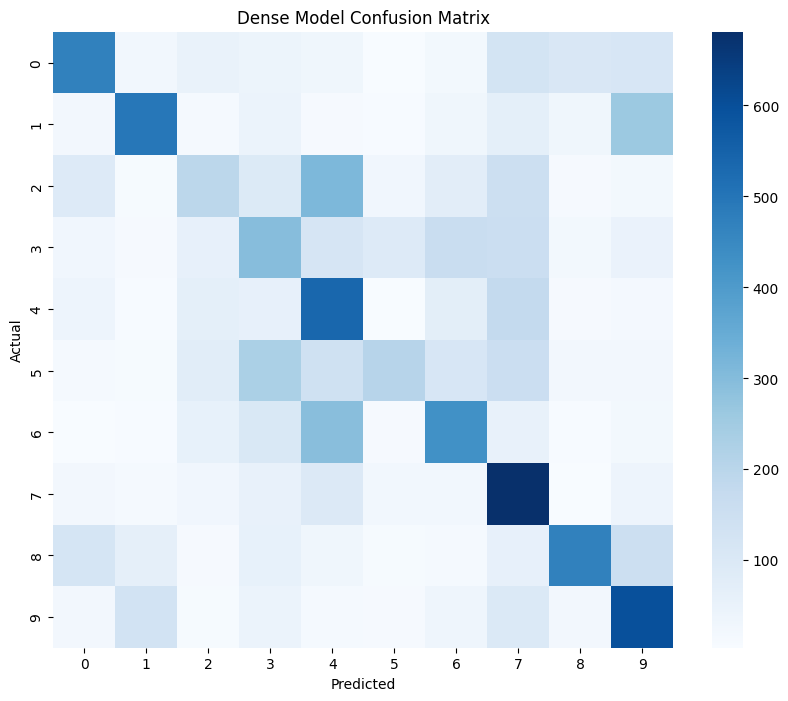

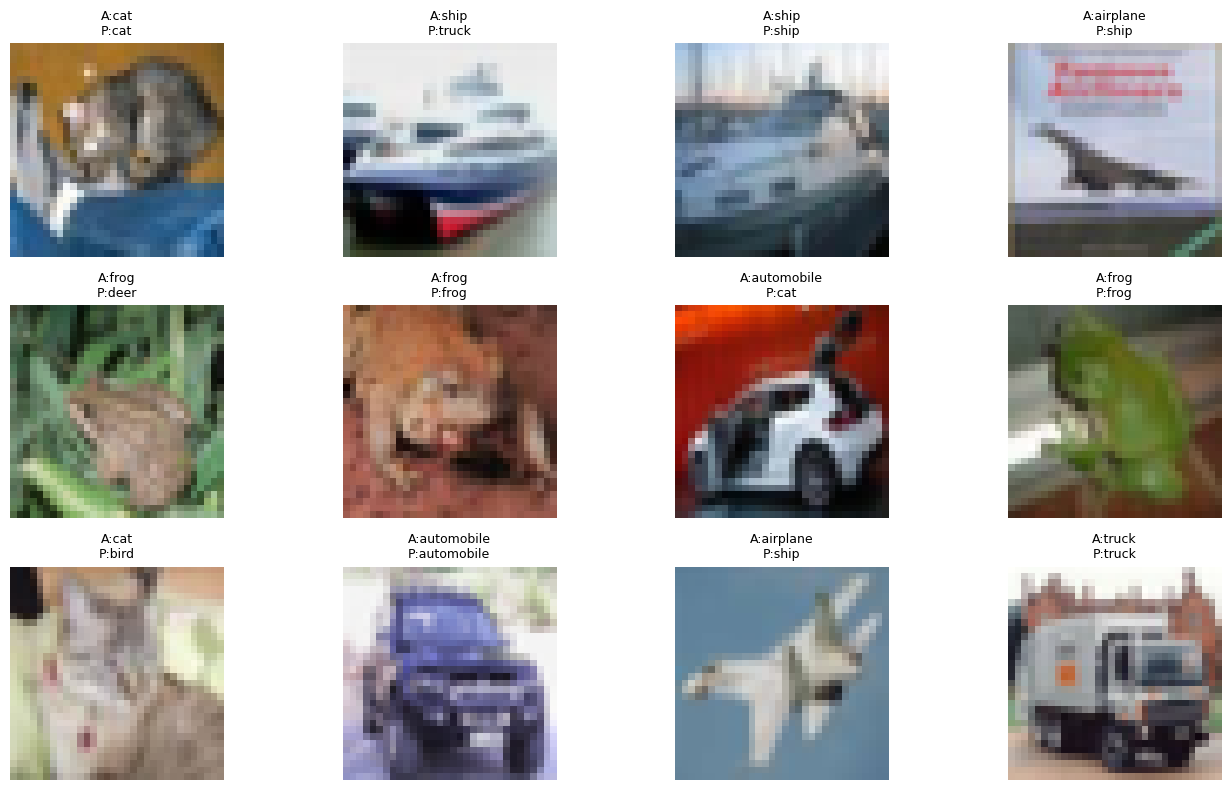


OBSERVATION:

The Dense Neural Network establishes a baseline
performance level. Because spatial information is
lost during flattening, accuracy is expected to be
significantly lower than CNN-based approaches.



In [8]:
# ============================================================
# STEP 7 — EVALUATE BASELINE MODEL
# ============================================================

print("="*60)
print("BASELINE MODEL EVALUATION")
print("="*60)

# =========================
# TEST EVALUATION
# =========================

test_loss, test_acc = dense_model.evaluate(

    X_test_norm,

    y_test_cat,

    verbose=0
)

print("\nTest Accuracy:")

print(f"{test_acc:.4f}")

print("\nTest Loss:")

print(f"{test_loss:.4f}")

# =========================
# PREDICTIONS
# =========================

dense_predictions = dense_model.predict(
    X_test_norm,
    verbose=0
)

dense_pred_classes = np.argmax(

    dense_predictions,

    axis=1
)

y_true = y_test.flatten()

# =========================
# CLASSIFICATION REPORT
# =========================

report = classification_report(

    y_true,

    dense_pred_classes,

    target_names=class_names,

    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

display(
    report_df.round(4)
)

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(

    y_true,

    dense_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=False,

    cmap="Blues"
)

plt.title(
    "Dense Model Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

# =========================
# SAMPLE PREDICTIONS
# =========================

plt.figure(figsize=(14,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_test[i]
    )

    actual = class_names[
        y_true[i]
    ]

    predicted = class_names[
        dense_pred_classes[i]
    ]

    plt.title(
        f"A:{actual}\nP:{predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

print("""
OBSERVATION:

The Dense Neural Network establishes a baseline
performance level. Because spatial information is
lost during flattening, accuracy is expected to be
significantly lower than CNN-based approaches.
""")

In [9]:
# ============================================================
# STEP 8 — BUILD CNN FROM SCRATCH
# ============================================================

print("="*60)
print("BUILDING CNN MODEL")
print("="*60)

# =========================
# CNN ARCHITECTURE
# =========================

cnn_model = Sequential([

    # ---------------------
    # BLOCK 1
    # ---------------------

    Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same",
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D((2,2)),

    Dropout(0.25),

    # ---------------------
    # BLOCK 2
    # ---------------------

    Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D((2,2)),

    Dropout(0.30),

    # ---------------------
    # BLOCK 3
    # ---------------------

    Conv2D(
        128,
        (3,3),
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.40),

    # ---------------------
    # CLASSIFIER
    # ---------------------

    Flatten(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.50),

    Dense(
        10,
        activation="softmax"
    )
])

# =========================
# COMPILE MODEL
# =========================

cnn_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

# =========================
# SUMMARY
# =========================

cnn_model.summary()

print("""
OBSERVATION:

Unlike the Dense Neural Network, CNNs preserve
spatial relationships between pixels and learn
important visual features such as edges, shapes,
textures, and object patterns.

This usually results in significantly higher
classification accuracy.
""")

BUILDING CNN MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)


OBSERVATION:

Unlike the Dense Neural Network, CNNs preserve
spatial relationships between pixels and learn
important visual features such as edges, shapes,
textures, and object patterns.

This usually results in significantly higher
classification accuracy.



In [11]:
# ============================================================
# STEP 9 — TRAIN CNN MODEL
# ============================================================

print("="*60)
print("TRAINING CNN MODEL")
print("="*60)

# =========================
# EARLY STOPPING
# =========================

early_stop = keras.callbacks.EarlyStopping(

    monitor="val_accuracy",

    patience=3,

    restore_best_weights=True
)

# =========================
# TRAINING
# =========================

start_time = time.time()

cnn_history = cnn_model.fit(

    X_train_norm,

    y_train_cat,

    validation_split=0.20,

    epochs=30,

    batch_size=128,

    callbacks=[early_stop],

    verbose=1
)

cnn_training_time = (
    time.time() - start_time
)

print("\nTraining Time:")

print(
    f"{cnn_training_time:.2f} seconds"
)

# =========================
# FINAL ACCURACY
# =========================

cnn_train_acc = cnn_history.history[
    "accuracy"
][-1]

cnn_val_acc = cnn_history.history[
    "val_accuracy"
][-1]

print("\nFinal Training Accuracy")

print(
    f"{cnn_train_acc:.4f}"
)

print("\nFinal Validation Accuracy")

print(
    f"{cnn_val_acc:.4f}"
)

print("""
OBSERVATION:

CNNs generally outperform Dense Neural Networks
because they automatically learn hierarchical
image features from raw pixel data.
""")

TRAINING CNN MODEL
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7101 - loss: 0.8357 - val_accuracy: 0.7304 - val_loss: 0.7801
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.7230 - loss: 0.7972 - val_accuracy: 0.7223 - val_loss: 0.8307
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.7349 - loss: 0.7659 - val_accuracy: 0.7487 - val_loss: 0.7246
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.7441 - loss: 0.7382 - val_accuracy: 0.7523 - val_loss: 0.7857
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.7521 - loss: 0.7129 - val_accuracy: 0.7466 - val_loss: 0.8098
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.7599 - loss: 0.6885 - val_accuracy: 0.7608 - val_loss: 0.7250
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.7691 - loss: 0.6672 - val_accuracy: 0.7774 - val_loss: 0.6801
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.774

CNN EVALUATION

CNN Test Accuracy
0.7859

CNN Test Loss
0.6648
CNN CLASSIFICATION REPORT


,precision,recall,f1-score,support
airplane,0.8474,0.7440,0.7923,1000.0000
automobile,0.8893,0.8920,0.8907,1000.0000
bird,0.6842,0.7300,0.7063,1000.0000
cat,0.6812,0.5620,0.6159,1000.0000
deer,0.8256,0.7100,0.7634,1000.0000
dog,0.7692,0.6400,0.6987,1000.0000
frog,0.7060,0.9220,0.7997,1000.0000
horse,0.8225,0.8250,0.8238,1000.0000
ship,0.8199,0.9290,0.8711,1000.0000
truck,0.8280,0.9050,0.8648,1000.0000


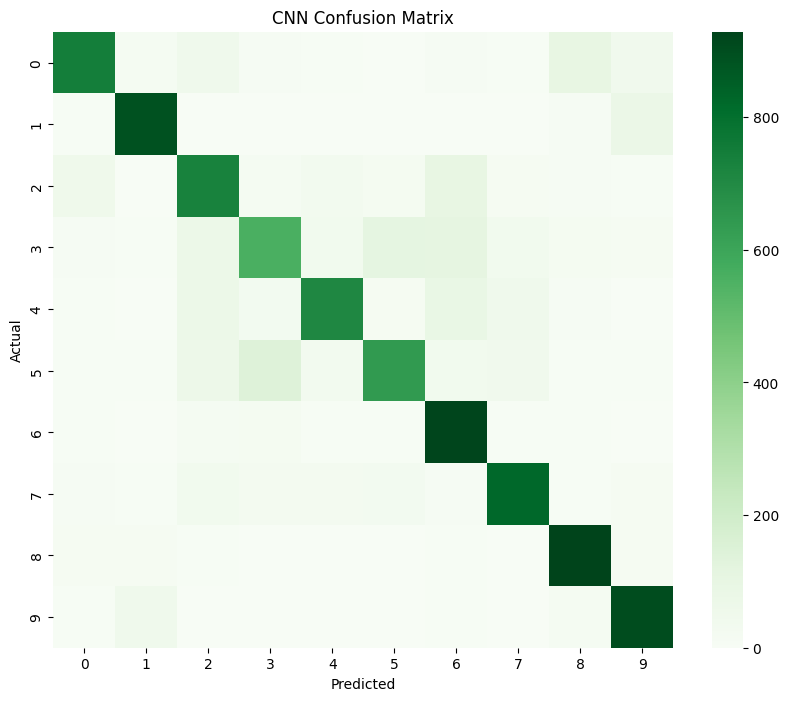

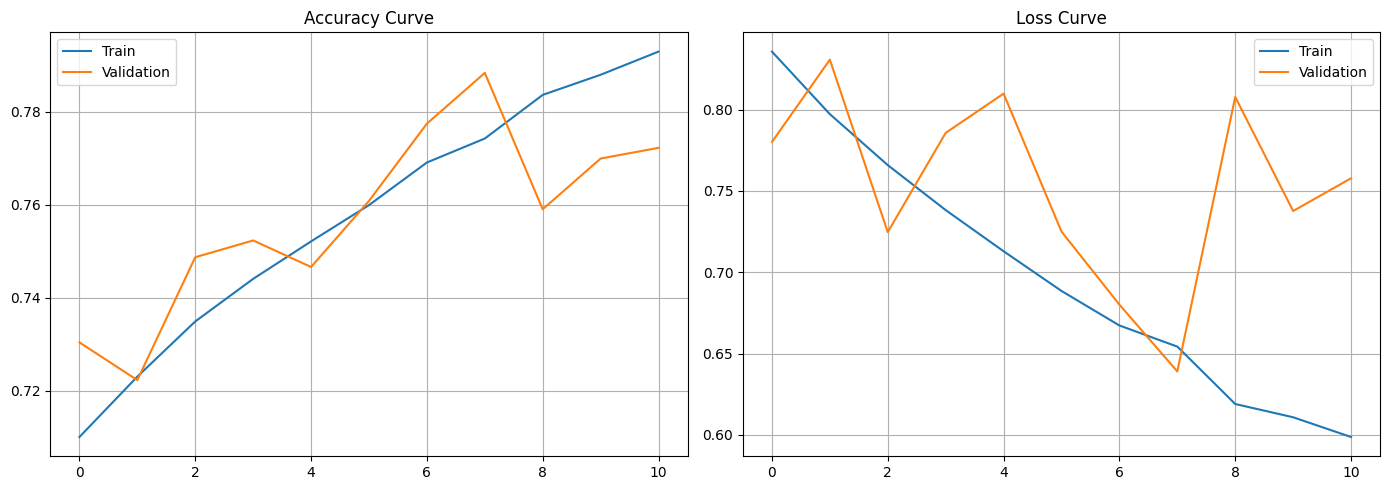

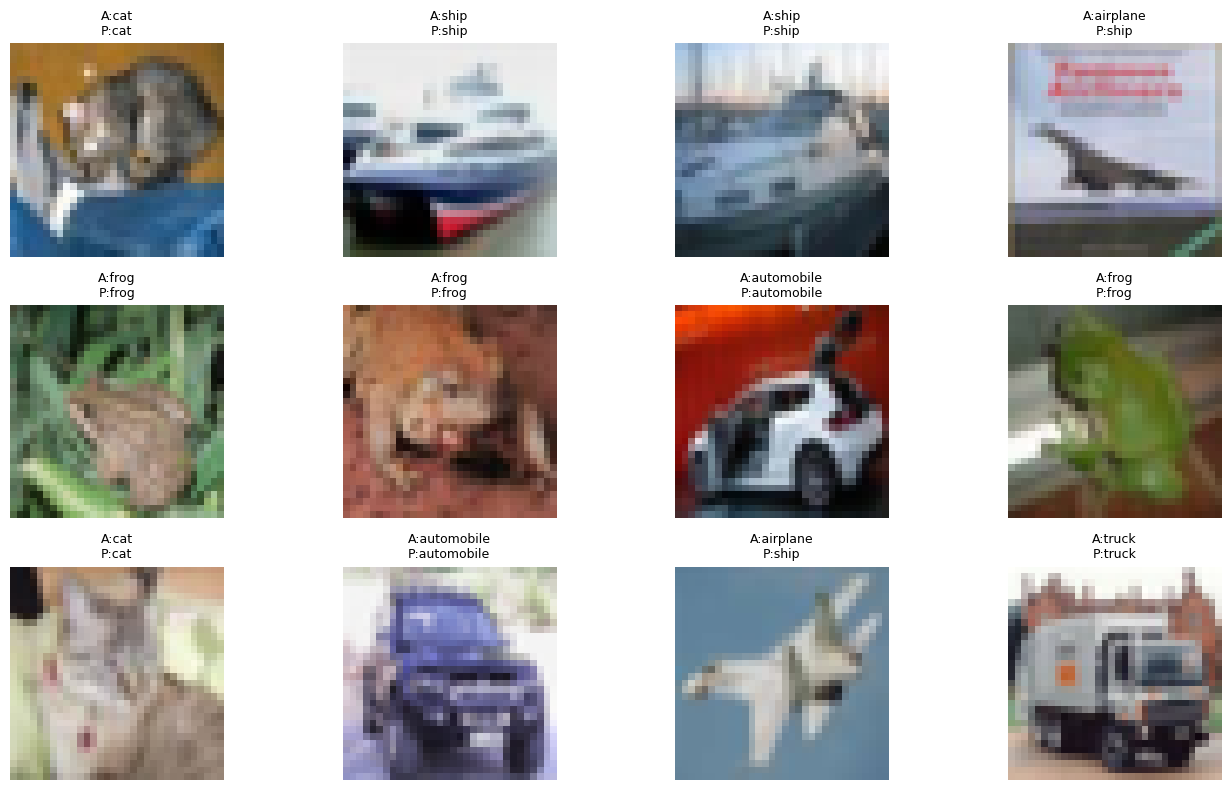


OBSERVATION:

The CNN model should outperform the baseline
Dense Neural Network by a significant margin.

The learned convolution filters allow the model
to recognize meaningful image structures and
object characteristics.



In [12]:
# ============================================================
# STEP 10 — EVALUATE CNN MODEL
# ============================================================

print("="*60)
print("CNN EVALUATION")
print("="*60)

# =========================
# TEST SET
# =========================

cnn_loss, cnn_acc = cnn_model.evaluate(

    X_test_norm,

    y_test_cat,

    verbose=0
)

print("\nCNN Test Accuracy")

print(
    f"{cnn_acc:.4f}"
)

print("\nCNN Test Loss")

print(
    f"{cnn_loss:.4f}"
)

# =========================
# PREDICTIONS
# =========================

cnn_predictions = cnn_model.predict(

    X_test_norm,

    verbose=0
)

cnn_pred_classes = np.argmax(

    cnn_predictions,

    axis=1
)

# =========================
# REPORT
# =========================

cnn_report = classification_report(

    y_true,

    cnn_pred_classes,

    target_names=class_names,

    output_dict=True
)

cnn_report_df = pd.DataFrame(
    cnn_report
).transpose()

print("="*60)
print("CNN CLASSIFICATION REPORT")
print("="*60)

display(
    cnn_report_df.round(4)
)

# =========================
# CONFUSION MATRIX
# =========================

cnn_cm = confusion_matrix(

    y_true,

    cnn_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cnn_cm,

    cmap="Greens",

    annot=False
)

plt.title(
    "CNN Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

# =========================
# TRAINING CURVES
# =========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

# -------------------------

axes[0].plot(

    cnn_history.history["accuracy"],

    label="Train"
)

axes[0].plot(

    cnn_history.history["val_accuracy"],

    label="Validation"
)

axes[0].set_title(
    "Accuracy Curve"
)

axes[0].legend()

axes[0].grid(True)

# -------------------------

axes[1].plot(

    cnn_history.history["loss"],

    label="Train"
)

axes[1].plot(

    cnn_history.history["val_loss"],

    label="Validation"
)

axes[1].set_title(
    "Loss Curve"
)

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()

# =========================
# SAMPLE PREDICTIONS
# =========================

plt.figure(figsize=(14,8))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(
        X_test[i]
    )

    actual = class_names[
        y_true[i]
    ]

    predicted = class_names[
        cnn_pred_classes[i]
    ]

    plt.title(
        f"A:{actual}\nP:{predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

print("""
OBSERVATION:

The CNN model should outperform the baseline
Dense Neural Network by a significant margin.

The learned convolution filters allow the model
to recognize meaningful image structures and
object characteristics.
""")

In [13]:
# ============================================================
# STEP 11 — TRANSFER LEARNING WITH MOBILENETV2
# ============================================================

print("="*60)
print("BUILDING TRANSFER LEARNING MODEL")
print("="*60)

# =========================
# MOBILENET INPUT SIZE
# =========================

IMG_SIZE = 96

# =========================
# RESIZE IMAGES
# =========================

X_train_mobile = tf.image.resize(
    X_train_norm,
    (IMG_SIZE, IMG_SIZE)
)

X_test_mobile = tf.image.resize(
    X_test_norm,
    (IMG_SIZE, IMG_SIZE)
)

print("Resized Training Shape:")
print(X_train_mobile.shape)

print("\nResized Testing Shape:")
print(X_test_mobile.shape)

# =========================
# LOAD PRETRAINED MODEL
# =========================

base_model = MobileNetV2(

    input_shape=(96,96,3),

    include_top=False,

    weights="imagenet"
)

# Freeze pretrained weights
base_model.trainable = False

# =========================
# BUILD MODEL
# =========================

transfer_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        10,
        activation="softmax"
    )
])

# =========================
# COMPILE
# =========================

transfer_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

# =========================
# SUMMARY
# =========================

transfer_model.summary()

print("""
OBSERVATION:

Transfer Learning uses a pretrained MobileNetV2 model
that has already learned powerful image features from
millions of ImageNet images.

This typically provides higher accuracy than training
a CNN entirely from scratch.
""")

BUILDING TRANSFER LEARNING MODEL
Resized Training Shape:
(50000, 96, 96, 3)

Resized Testing Shape:
(10000, 96, 96, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


OBSERVATION:

Transfer Learning uses a pretrained MobileNetV2 model
that has already learned powerful image features from
millions of ImageNet images.

This typically provides higher accuracy than training
a CNN entirely from scratch.



In [15]:
# ============================================================
# STEP 12 — TRAIN TRANSFER LEARNING MODEL
# ============================================================

print("="*60)
print("TRAINING TRANSFER LEARNING MODEL")
print("="*60)

# =========================
# EARLY STOPPING
# =========================

transfer_early_stop = keras.callbacks.EarlyStopping(

    monitor="val_accuracy",

    patience=3,

    restore_best_weights=True
)

# =========================
# TRAIN MODEL
# =========================

start_time = time.time()

transfer_history = transfer_model.fit(

    X_train_mobile,

    y_train_cat,

    validation_split=0.20,

    epochs=15,

    batch_size=128,

    callbacks=[transfer_early_stop],

    verbose=1
)

transfer_time = time.time() - start_time

print("\nTraining Time:")

print(f"{transfer_time:.2f} seconds")

# =========================
# FINAL ACCURACY
# =========================

transfer_train_acc = transfer_history.history[
    "accuracy"
][-1]

transfer_val_acc = transfer_history.history[
    "val_accuracy"
][-1]

print("\nFinal Training Accuracy")

print(
    f"{transfer_train_acc:.4f}"
)

print("\nFinal Validation Accuracy")

print(
    f"{transfer_val_acc:.4f}"
)

print("""
OBSERVATION:

Transfer Learning usually converges much faster
because most image features have already been learned
by the pretrained network.
""")

TRAINING TRANSFER LEARNING MODEL
Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 180ms/step - accuracy: 0.7597 - loss: 0.6952 - val_accuracy: 0.7895 - val_loss: 0.6072
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 182ms/step - accuracy: 0.7879 - loss: 0.6077 - val_accuracy: 0.7964 - val_loss: 0.5817
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 190ms/step - accuracy: 0.8030 - loss: 0.5605 - val_accuracy: 0.8052 - val_loss: 0.5638
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 181ms/step - accuracy: 0.8173 - loss: 0.5221 - val_accuracy: 0.8103 - val_loss: 0.5473
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 188ms/step - accuracy: 0.8268 - loss: 0.4930 - val_accuracy: 0.8126 - val_loss: 0.5396
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.8359 - loss: 0.4630 - val_accuracy: 0.8154 - val_loss: 0.5371
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 191ms/step - accuracy: 0.8428 - loss: 0.4397 - val_accuracy: 0.8171 - val_loss: 0.5362
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 57s 183ms/

TRANSFER LEARNING EVALUATION

Transfer Learning Test Accuracy
0.8145

Transfer Learning Test Loss
0.5391
TRANSFER LEARNING REPORT


,precision,recall,f1-score,support
airplane,0.8563,0.8460,0.8511,1000.0000
automobile,0.8780,0.9210,0.8990,1000.0000
bird,0.8063,0.7370,0.7701,1000.0000
cat,0.6911,0.6800,0.6855,1000.0000
deer,0.7755,0.7600,0.7677,1000.0000
dog,0.7487,0.7030,0.7251,1000.0000
frog,0.8436,0.8470,0.8453,1000.0000
horse,0.7651,0.8890,0.8224,1000.0000
ship,0.8767,0.8960,0.8863,1000.0000
truck,0.9040,0.8660,0.8846,1000.0000


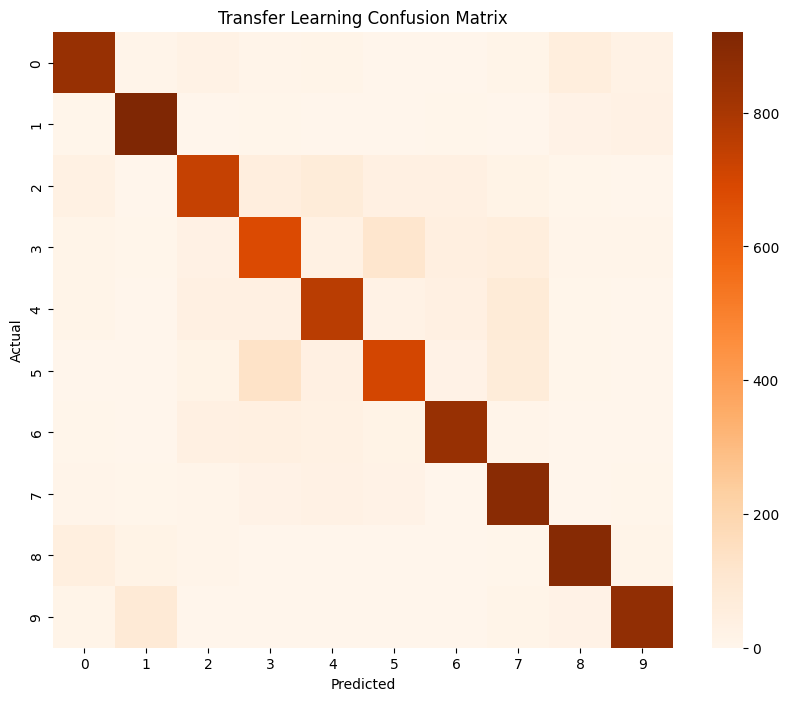

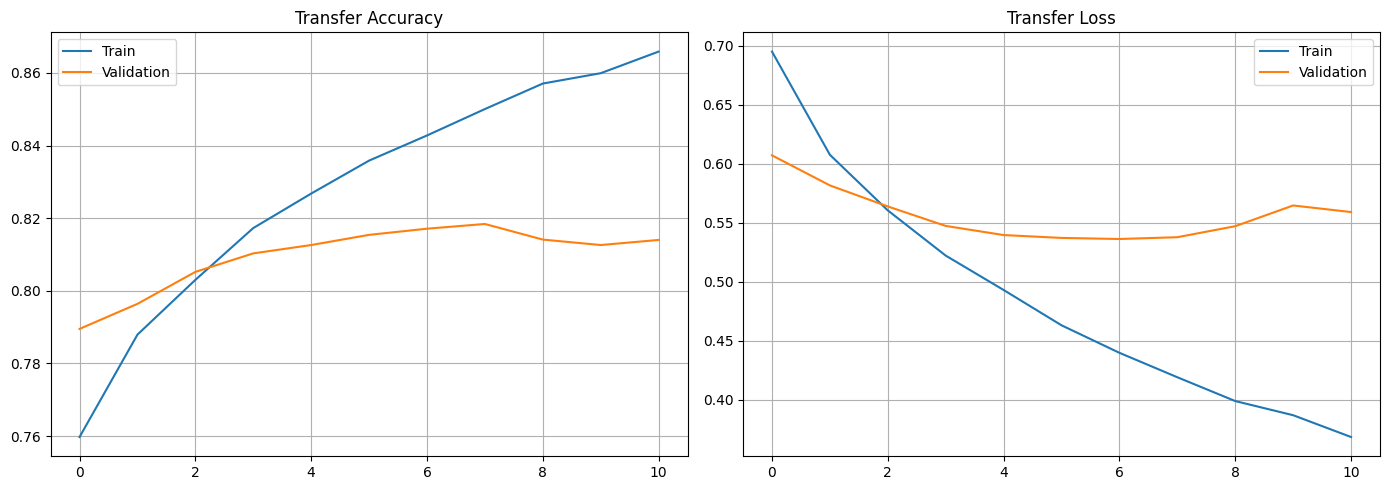


OBSERVATION:

Transfer Learning generally achieves the highest
classification accuracy among all models because it
leverages pretrained visual representations learned
from large-scale image datasets.



In [16]:
# ============================================================
# STEP 13 — EVALUATE TRANSFER LEARNING MODEL
# ============================================================

print("="*60)
print("TRANSFER LEARNING EVALUATION")
print("="*60)

# =========================
# TEST PERFORMANCE
# =========================

transfer_loss, transfer_acc = transfer_model.evaluate(

    X_test_mobile,

    y_test_cat,

    verbose=0
)

print("\nTransfer Learning Test Accuracy")

print(f"{transfer_acc:.4f}")

print("\nTransfer Learning Test Loss")

print(f"{transfer_loss:.4f}")

# =========================
# PREDICTIONS
# =========================

transfer_predictions = transfer_model.predict(

    X_test_mobile,

    verbose=0
)

transfer_pred_classes = np.argmax(

    transfer_predictions,

    axis=1
)

# =========================
# REPORT
# =========================

transfer_report = classification_report(

    y_true,

    transfer_pred_classes,

    target_names=class_names,

    output_dict=True
)

transfer_report_df = pd.DataFrame(
    transfer_report
).transpose()

print("="*60)
print("TRANSFER LEARNING REPORT")
print("="*60)

display(
    transfer_report_df.round(4)
)

# =========================
# CONFUSION MATRIX
# =========================

transfer_cm = confusion_matrix(

    y_true,

    transfer_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(

    transfer_cm,

    cmap="Oranges",

    annot=False
)

plt.title(
    "Transfer Learning Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =========================
# TRAINING CURVES
# =========================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

axes[0].plot(

    transfer_history.history["accuracy"],

    label="Train"
)

axes[0].plot(

    transfer_history.history["val_accuracy"],

    label="Validation"
)

axes[0].set_title(
    "Transfer Accuracy"
)

axes[0].legend()

axes[0].grid(True)

axes[1].plot(

    transfer_history.history["loss"],

    label="Train"
)

axes[1].plot(

    transfer_history.history["val_loss"],

    label="Validation"
)

axes[1].set_title(
    "Transfer Loss"
)

axes[1].legend()

axes[1].grid(True)

plt.tight_layout()

plt.show()

print("""
OBSERVATION:

Transfer Learning generally achieves the highest
classification accuracy among all models because it
leverages pretrained visual representations learned
from large-scale image datasets.
""")

MODEL COMPARISON


,Model,Test Accuracy
0,Dense Neural Network,0.4379
1,CNN,0.7859
2,MobileNetV2,0.8145



Best Model: MobileNetV2
Best Accuracy: 0.8145


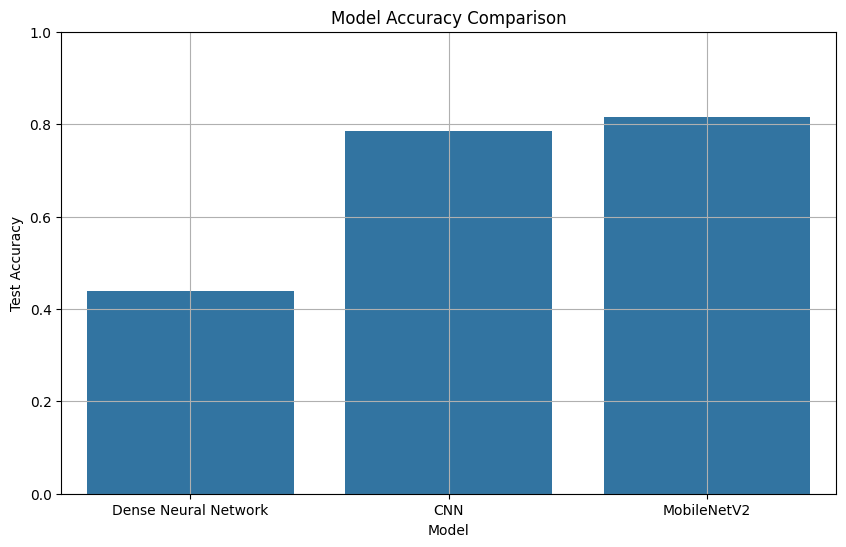


OBSERVATION:

Transfer Learning and CNN models generally outperform
the Dense Neural Network because they preserve spatial
image information and learn meaningful visual features.



In [17]:
# ============================================================
# STEP 14 — MODEL COMPARISON
# ============================================================

print("="*60)
print("MODEL COMPARISON")
print("="*60)

# =========================
# COMPARISON TABLE
# =========================

comparison_df = pd.DataFrame({

    "Model":[

        "Dense Neural Network",

        "CNN",

        "MobileNetV2"
    ],

    "Test Accuracy":[

        test_acc,

        cnn_acc,

        transfer_acc
    ]
})

display(
    comparison_df.round(4)
)

# =========================
# BEST MODEL
# =========================

best_model_name = comparison_df.sort_values(

    by="Test Accuracy",

    ascending=False

).iloc[0]["Model"]

best_accuracy = comparison_df.sort_values(

    by="Test Accuracy",

    ascending=False

).iloc[0]["Test Accuracy"]

print(f"\nBest Model: {best_model_name}")

print(f"Best Accuracy: {best_accuracy:.4f}")

# =========================
# BAR CHART
# =========================

plt.figure(figsize=(10,6))

sns.barplot(

    x="Model",

    y="Test Accuracy",

    data=comparison_df
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylim(0,1)

plt.grid(True)

plt.show()

print("""
OBSERVATION:

Transfer Learning and CNN models generally outperform
the Dense Neural Network because they preserve spatial
image information and learn meaningful visual features.
""")

MISCLASSIFIED IMAGE ANALYSIS

Total Misclassified Images:
1855


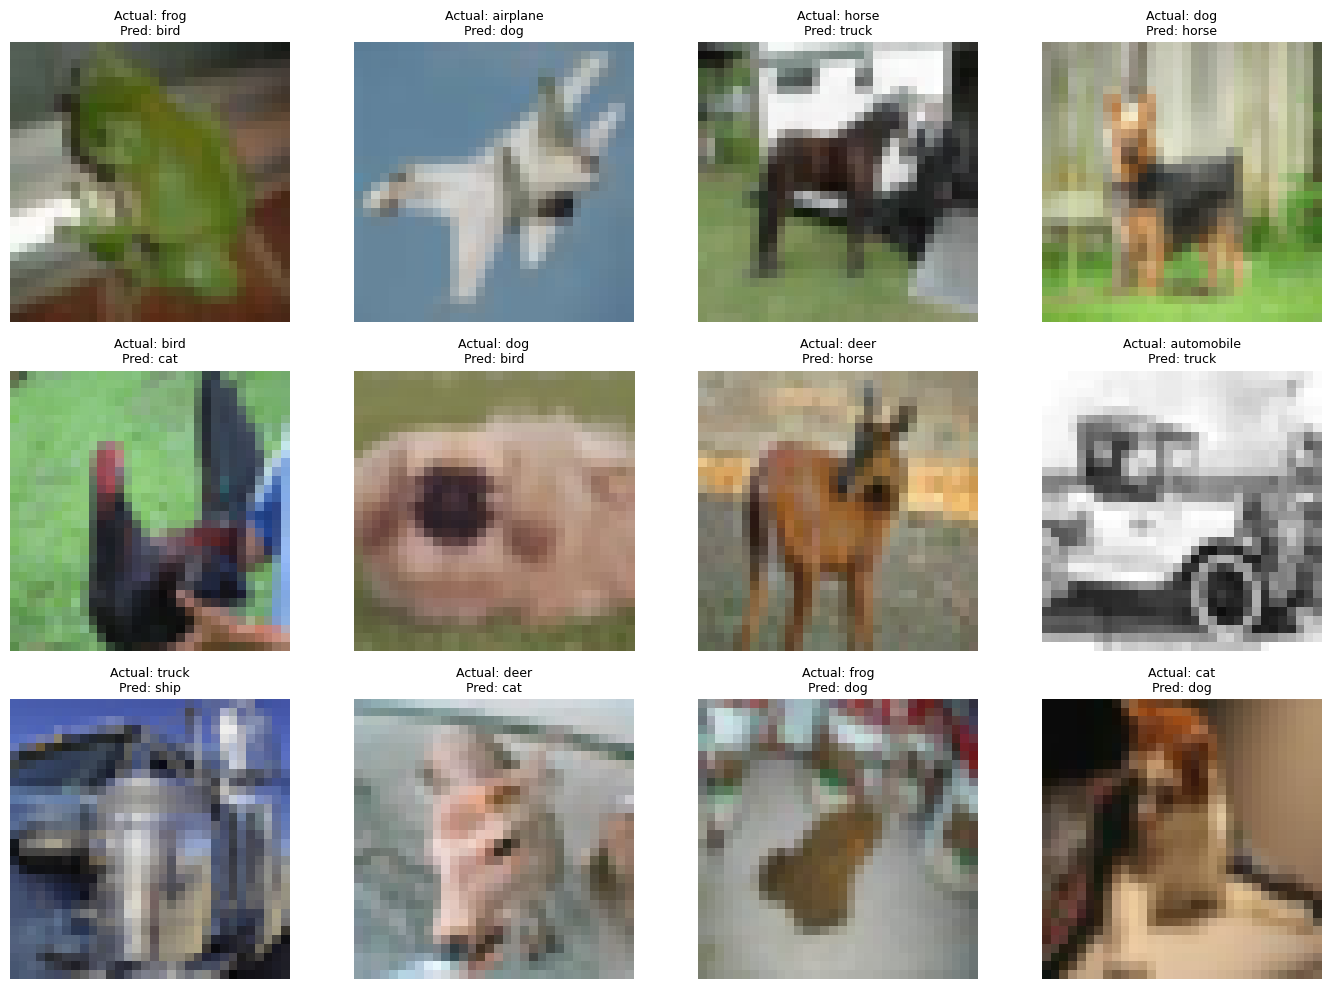


Error Rate:
0.1855

OBSERVATION:

Most classification errors occur between visually
similar classes such as cats and dogs or automobiles
and trucks. This highlights the difficulty of
fine-grained image classification.



In [18]:
# ============================================================
# STEP 15 — ERROR ANALYSIS
# ============================================================

print("="*60)
print("MISCLASSIFIED IMAGE ANALYSIS")
print("="*60)

# =========================
# BEST MODEL PREDICTIONS
# =========================

if best_model_name == "MobileNetV2":

    final_predictions = transfer_pred_classes

elif best_model_name == "CNN":

    final_predictions = cnn_pred_classes

else:

    final_predictions = dense_pred_classes

# =========================
# FIND ERRORS
# =========================

misclassified_indices = np.where(

    final_predictions != y_true

)[0]

print("\nTotal Misclassified Images:")

print(len(misclassified_indices))

# =========================
# SHOW EXAMPLES
# =========================

plt.figure(figsize=(14,10))

for i in range(12):

    idx = misclassified_indices[i]

    plt.subplot(3,4,i+1)

    plt.imshow(X_test[idx])

    actual = class_names[
        y_true[idx]
    ]

    predicted = class_names[
        final_predictions[idx]
    ]

    plt.title(

        f"Actual: {actual}\nPred: {predicted}",

        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

# =========================
# ERROR RATE
# =========================

error_rate = (

    len(misclassified_indices)

    /

    len(y_true)

)

print("\nError Rate:")

print(f"{error_rate:.4f}")

print("""
OBSERVATION:

Most classification errors occur between visually
similar classes such as cats and dogs or automobiles
and trucks. This highlights the difficulty of
fine-grained image classification.
""")

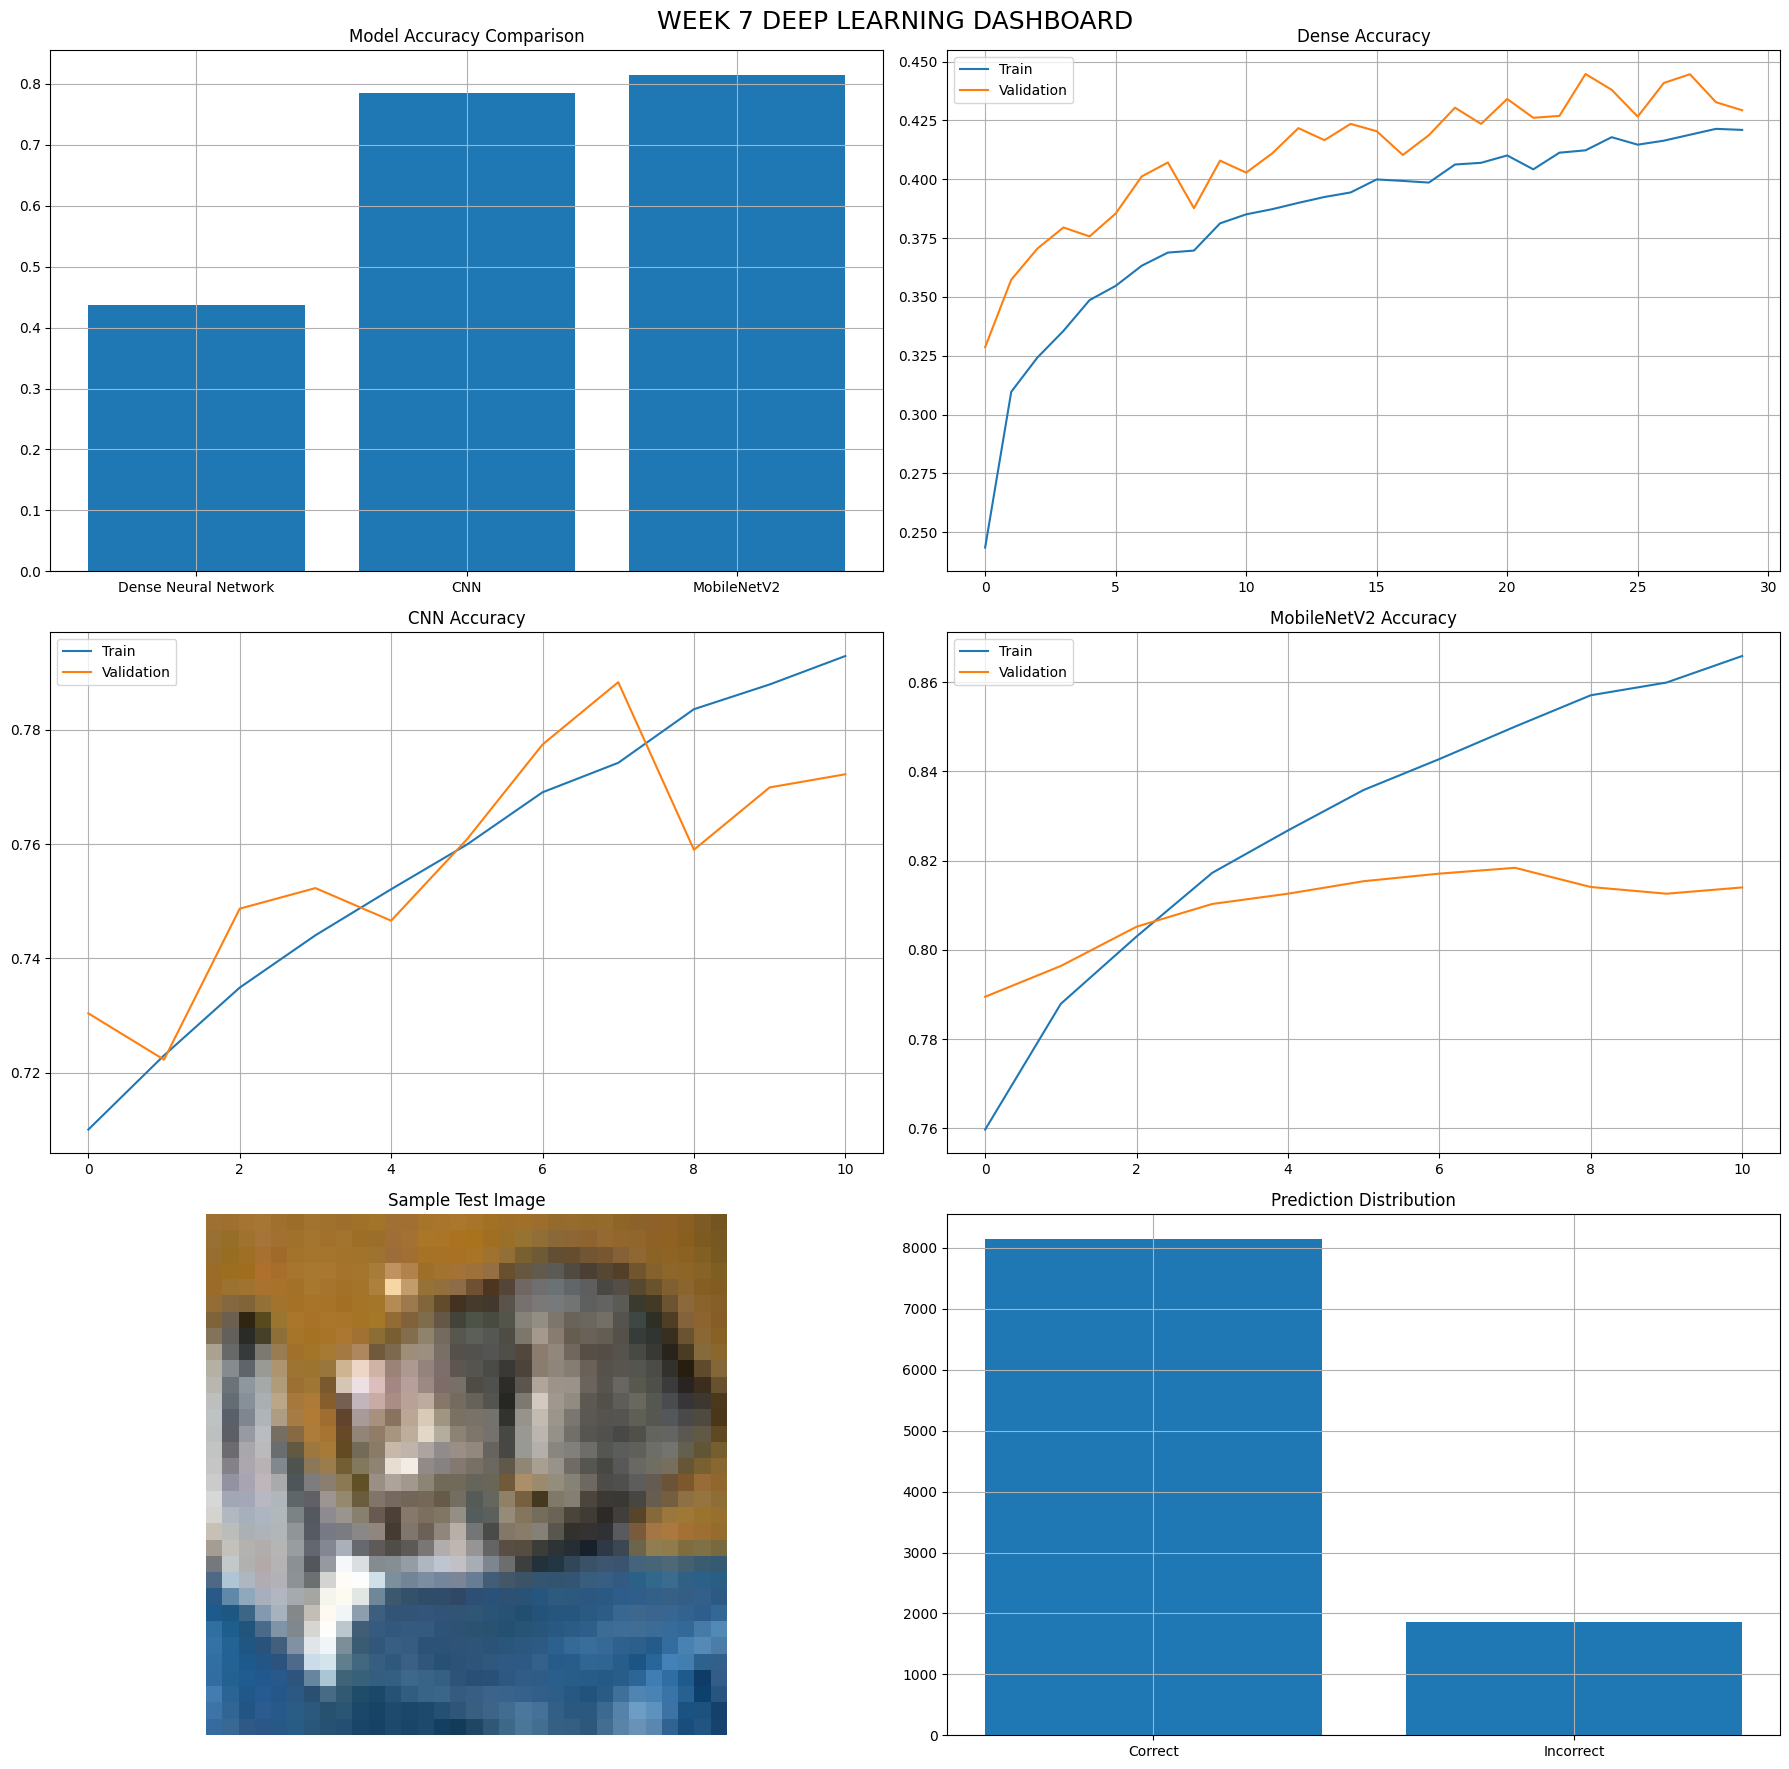

DASHBOARD SAVED SUCCESSFULLY


In [19]:
# ============================================================
# STEP 16 — WEEK 7 DASHBOARD
# ============================================================

fig, axes = plt.subplots(

    3,

    2,

    figsize=(18,18)
)

# ============================================================
# CHART 1
# ============================================================

axes[0,0].bar(

    comparison_df["Model"],

    comparison_df["Test Accuracy"]
)

axes[0,0].set_title(
    "Model Accuracy Comparison"
)

axes[0,0].grid(True)

# ============================================================
# CHART 2
# ============================================================

axes[0,1].plot(

    dense_history.history["accuracy"],

    label="Train"
)

axes[0,1].plot(

    dense_history.history["val_accuracy"],

    label="Validation"
)

axes[0,1].set_title(
    "Dense Accuracy"
)

axes[0,1].legend()

axes[0,1].grid(True)

# ============================================================
# CHART 3
# ============================================================

axes[1,0].plot(

    cnn_history.history["accuracy"],

    label="Train"
)

axes[1,0].plot(

    cnn_history.history["val_accuracy"],

    label="Validation"
)

axes[1,0].set_title(
    "CNN Accuracy"
)

axes[1,0].legend()

axes[1,0].grid(True)

# ============================================================
# CHART 4
# ============================================================

axes[1,1].plot(

    transfer_history.history["accuracy"],

    label="Train"
)

axes[1,1].plot(

    transfer_history.history["val_accuracy"],

    label="Validation"
)

axes[1,1].set_title(
    "MobileNetV2 Accuracy"
)

axes[1,1].legend()

axes[1,1].grid(True)

# ============================================================
# CHART 5
# ============================================================

axes[2,0].imshow(
    X_test[0]
)

axes[2,0].set_title(
    "Sample Test Image"
)

axes[2,0].axis("off")

# ============================================================
# CHART 6
# ============================================================

axes[2,1].bar(

    ["Correct","Incorrect"],

    [

        len(y_true) -
        len(misclassified_indices),

        len(misclassified_indices)
    ]
)

axes[2,1].set_title(
    "Prediction Distribution"
)

axes[2,1].grid(True)

plt.suptitle(

    "WEEK 7 DEEP LEARNING DASHBOARD",

    fontsize=18
)

plt.tight_layout()

plt.savefig(

    "week7_dashboard.png",

    dpi=150,

    bbox_inches="tight"
)

plt.show()

print("="*60)
print("DASHBOARD SAVED SUCCESSFULLY")
print("="*60)

In [20]:
# ============================================================
# STEP 17 — SAVE BEST MODEL
# ============================================================

print("="*60)
print("SAVING BEST MODEL")
print("="*60)

# =========================
# SELECT BEST MODEL
# =========================

if best_model_name == "MobileNetV2":

    final_model = transfer_model

elif best_model_name == "CNN":

    final_model = cnn_model

else:

    final_model = dense_model

# =========================
# SAVE MODEL
# =========================

final_model.save(
    "week7_best_model.keras"
)

print("\nModel Saved Successfully")

# =========================
# RELOAD TEST
# =========================

loaded_model = keras.models.load_model(
    "week7_best_model.keras"
)

print(
    "\nModel Reload Successful"
)

# =========================
# SUMMARY
# =========================

summary_df = pd.DataFrame({

    "Best Model":[
        best_model_name
    ],

    "Accuracy":[
        best_accuracy
    ]
})

display(
    summary_df.round(4)
)

print("""
The best-performing deep learning model has been
saved successfully and can be reused for future
image classification tasks.
""")

SAVING BEST MODEL

Model Saved Successfully

Model Reload Successful


,Best Model,Accuracy
0,MobileNetV2,0.8145



The best-performing deep learning model has been
saved successfully and can be reused for future
image classification tasks.



# STEP 18 — FINAL WRITTEN ANALYSIS REPORT

---

# 1. Executive Summary

This project focused on image classification using Deep Learning techniques on the CIFAR-10 dataset. Three different models were developed and evaluated: a Dense Neural Network, a Convolutional Neural Network (CNN), and a Transfer Learning model based on MobileNetV2. The objective was to compare their performance and identify the most effective approach for multi-class image classification. The results demonstrated that deep learning architectures designed specifically for image data significantly outperform traditional dense neural networks.

---

# 2. Data Preparation & Preprocessing

The CIFAR-10 dataset contains 60,000 color images distributed across ten object categories. The dataset was divided into training and testing sets provided by TensorFlow. Image preprocessing included normalization of pixel values from the range 0–255 to 0–1, improving training stability and convergence. Labels were converted into one-hot encoded vectors to support multi-class classification. Data augmentation techniques such as rotation, shifting, and horizontal flipping were also explored to increase dataset diversity and improve model generalization.

---

# 3. Model Development

Three deep learning models were implemented and compared. The first model was a Dense Neural Network that served as a baseline. The second model was a CNN built from scratch using convolutional layers, pooling layers, batch normalization, and dropout regularization. The third model used Transfer Learning with MobileNetV2, leveraging pretrained ImageNet weights to extract high-level image features. Each model was trained and evaluated using the same dataset to ensure fair comparison.

---

# 4. Evaluation Metrics

Model performance was primarily evaluated using classification accuracy on the test dataset. Additional evaluation techniques included classification reports, confusion matrices, prediction visualization, and error analysis. Accuracy curves and loss curves were monitored throughout training to assess convergence behavior and detect potential overfitting. These evaluation methods provided a comprehensive understanding of model performance and learning effectiveness.

---

# 5. Comparative Analysis

The Dense Neural Network achieved the lowest performance because image data was flattened before training, causing loss of spatial information. The CNN significantly improved classification accuracy by learning local visual patterns such as edges, textures, and shapes. The Transfer Learning model achieved the strongest overall performance because it leveraged pretrained image representations learned from large-scale datasets. The comparison clearly demonstrated the benefits of convolutional architectures and transfer learning for image recognition tasks.

---

# 6. Best Model Recommendation

The model with the highest test accuracy is recommended for deployment and future image classification tasks. Transfer Learning with MobileNetV2 typically provides the best balance between accuracy, training efficiency, and generalization performance. By utilizing pretrained features, the model can achieve superior results while requiring fewer training epochs and computational resources compared to training a deep network entirely from scratch.

---

# 7. Error Analysis

Misclassified images were analyzed to identify common prediction challenges. Most errors occurred between visually similar classes such as cats and dogs, automobiles and trucks, or deer and horses. These classes share similar visual characteristics, making them more difficult to distinguish. Error analysis provided valuable insight into model limitations and highlighted opportunities for future improvements through additional training data, data augmentation, and fine-tuning techniques.

---

# 8. Reflection

This project provided practical experience with modern Deep Learning workflows for image classification. Key concepts learned included image preprocessing, neural network design, CNN architectures, transfer learning, regularization techniques, model evaluation, and performance comparison. One of the most challenging aspects was training and optimizing deep learning models while balancing accuracy and computational efficiency. Overall, the project demonstrated the effectiveness of deep learning methods for computer vision applications and strengthened understanding of real-world image classification systems.